## 03 — PCA & UMAP

Applying PCA and UMAP for dimensionality reduction and visualization.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.config import PROCESSED_FILES, RANDOM_STATE

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

In [2]:
cust = pd.read_csv(PROCESSED_FILES["features"], index_col="CustomerID")
print(f"Shape: {cust.shape}")

Shape: (1000, 21)


### Standardize

In [3]:
from sklearn.preprocessing import StandardScaler

num_cols = cust.select_dtypes(include=[np.number]).columns
X = cust[num_cols].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Scaled shape: {X_scaled.shape}")

Scaled shape: (1000, 19)


### PCA

Components for 95% variance: 9


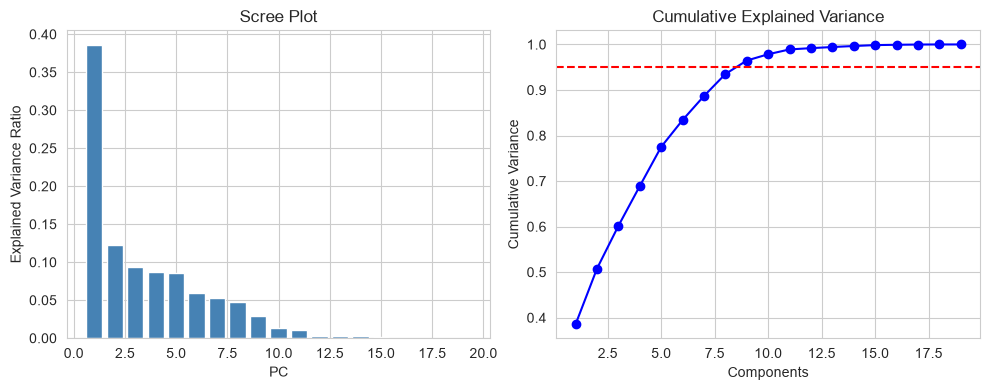

In [4]:
from sklearn.decomposition import PCA

pca = PCA(random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

cumulative = np.cumsum(pca.explained_variance_ratio_)
n_components = np.searchsorted(cumulative, 0.95) + 1
print(f"Components for 95% variance: {n_components}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, color="steelblue")
plt.xlabel("PC")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative)+1), cumulative, "bo-")
plt.axhline(y=0.95, color="r", linestyle="--")
plt.xlabel("Components")
plt.ylabel("Cumulative Variance")
plt.title("Cumulative Explained Variance")
plt.tight_layout()
plt.show()

### 2D PCA Projection

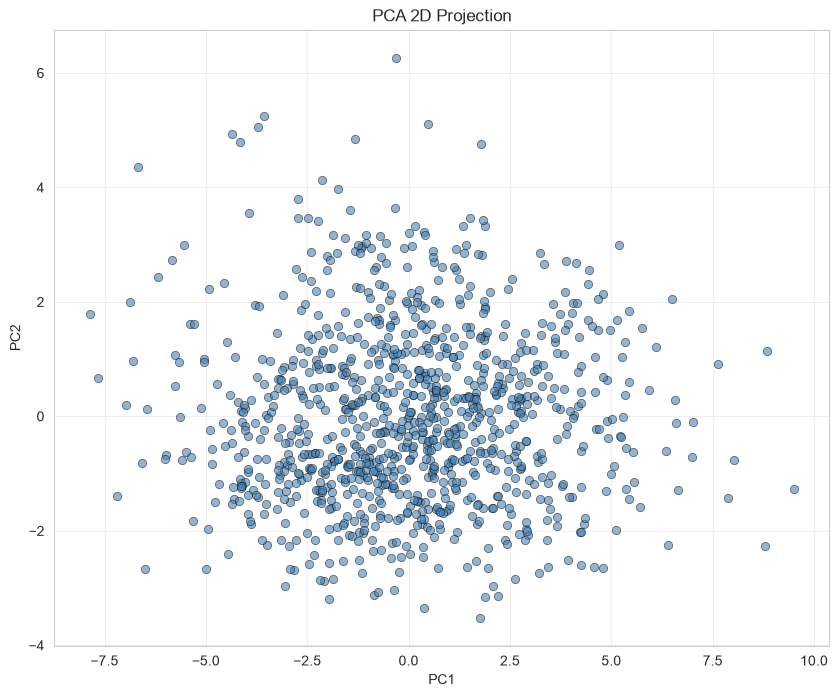

In [5]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)
plt.figure(figsize=(10, 8))
plt.scatter(pca_2d[:, 0], pca_2d[:, 1], alpha=0.6, c="steelblue", edgecolors="black", linewidth=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D Projection")
plt.grid(True, alpha=0.3)
plt.show()

### UMAP

C:\Users\Hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


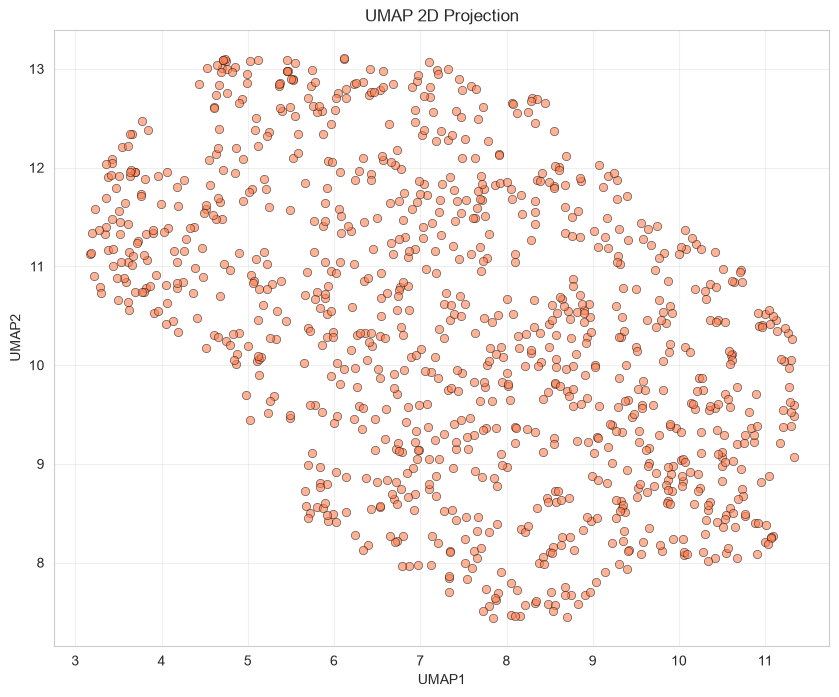

In [6]:
import umap

reducer = umap.UMAP(random_state=RANDOM_STATE)
X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
plt.scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.6, c="coral", edgecolors="black", linewidth=0.5)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP 2D Projection")
plt.grid(True, alpha=0.3)
plt.show()